In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      1
    Core(s) per socket:      96
    Socket(s):               2
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      56%
    CPU max MHz:             3715.4290
    CPU min MHz:             1500.0000
    BogoMIPS:                5099.64
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from scipy.optimize import fmin, minimize, LinearConstraint, Bounds

from efficient_fpt.multi_stage_cy import (
    compute_loss_parallel,
    print_num_threads,
    compute_tadaloss_parallel,
)

import sys, os

In [3]:
combined_pkl = "addm_data_all_a_20260222-212154.pkl"  # <-- adjust filename as needed

with open(combined_pkl, "rb") as f:
    all_data = pickle.load(f)
data_keys = sorted(all_data.keys())
print(f"Loaded combined pkl with {len(data_keys)} eta values: {data_keys}")

Loaded combined pkl with 11 eta values: [1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5]


In [4]:
num_data_list = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]

### Run maximum likelihood with aDDM likelihood function with different dataset size

In [5]:
paras_true_arr = np.zeros((len(num_data_list), len(data_keys), 4))
paras_mle_arr = np.zeros((len(num_data_list), len(data_keys), 4))

for i, data_name in enumerate(data_keys):
    for j, num_data in enumerate(num_data_list):
        data = all_data[data_name]
        a = data["a"]
        b = data["b"]
        x0 = data["x0"]
        eta_true = data["eta"]
        kappa_true = data["kappa"]
        r1_data = data["r1_data"][:num_data]
        r2_data = data["r2_data"][:num_data]
        flag_data = data["flag_data"][:num_data].astype(np.int32)
        sacc_data = data["sacc_array_padded_data"][:num_data, :]
        num_data, max_d = sacc_data.shape
        sigma = data["sigma"]
        T = data["T"]
        length_data = data["d_data"][:num_data].astype(np.int32)
        rt_data = data["decision_data"][:num_data, 0]
        choice_data = data["decision_data"][:num_data, 1].astype(np.int32)

        if j == 0:
            print(f"true params: [{eta_true:.2f}, {kappa_true:.2f}, {a:.2f}, {x0:.2f}]")

        # print("\nNumerical optimization for eta:")
        method = "trust-constr"
        # print("Using " + method)
        func = lambda paras: compute_loss_parallel(
            paras[1] * (r1_data - paras[0] * r2_data),
            paras[1] * (paras[0] * r1_data - r2_data),
            rt_data,
            choice_data,
            flag_data,
            sacc_data,
            length_data,
            max_d,
            sigma,
            paras[2],
            b,
            paras[3],
        )
        bounds = Bounds([0, 0, 0, -np.inf], [1, np.inf, np.inf, np.inf])
        con = LinearConstraint(
            [[0, 0, 1, 1], [0, 0, 1, -1]],
            lb=[0, 0],
            ub=[np.inf, np.inf],
        )
        initial_guess = [0.5, 0.5, 1.0, 0.0]
        # print("Initial guess:", initial_guess)
        # print()
        start_time = time.time()
        paras_opt_result = minimize(
            func,
            x0=initial_guess,
            bounds=bounds,
            constraints=con,
            method=method,
            options={"verbose": 0},
        )
        # print(f"Total time: {time.time() - start_time:.3f} seconds")
        if not paras_opt_result.success:
            print(f"WARNING: eta={eta_true} optimization failed.")
        mle = paras_opt_result["x"]
        paras_true_arr[j, i] = np.array([eta_true, kappa_true, a, x0])
        paras_mle_arr[j, i] = mle
        print(
            f"num_data: {num_data:5d},",
            f"mle: [{', '.join(f'{x:.5f}' for x in mle)}]",
        )

    print()

true params: [0.30, 0.50, 1.50, 0.50]
num_data:   100, mle: [0.19298, 0.57477, 1.57468, 0.51972]
num_data:   200, mle: [0.27397, 0.56210, 1.54486, 0.52324]
num_data:   400, mle: [0.30120, 0.54913, 1.51984, 0.54041]
num_data:   800, mle: [0.27259, 0.52221, 1.51671, 0.53145]
num_data:  1600, mle: [0.28795, 0.50969, 1.51114, 0.51150]
num_data:  3200, mle: [0.28870, 0.50475, 1.51013, 0.49982]
num_data:  6400, mle: [0.29503, 0.50073, 1.49794, 0.51163]
num_data: 12800, mle: [0.29339, 0.49946, 1.49595, 0.49735]
num_data: 25600, mle: [0.29381, 0.49853, 1.50355, 0.50117]

true params: [0.30, 0.50, 1.60, 0.50]
num_data:   100, mle: [0.20611, 0.51010, 1.65002, 0.56334]
num_data:   200, mle: [0.24655, 0.45290, 1.56295, 0.53504]
num_data:   400, mle: [0.25776, 0.45990, 1.58773, 0.55123]
num_data:   800, mle: [0.27203, 0.49719, 1.60115, 0.52646]
num_data:  1600, mle: [0.28331, 0.50574, 1.60891, 0.52061]
num_data:  3200, mle: [0.29142, 0.50981, 1.59489, 0.49323]
num_data:  6400, mle: [0.29992, 0.5082

### Run maximum likelihood with TADA likelihood function with different dataset size

In [6]:
paras_true_arr = np.zeros((len(num_data_list), len(data_keys), 4))
paras_tada_arr = np.zeros((len(num_data_list), len(data_keys), 4))

for i, data_name in enumerate(data_keys):
    for j, num_data in enumerate(num_data_list):
        data = all_data[data_name]
        a = data["a"]
        b = data["b"]
        x0 = data["x0"]
        eta_true = data["eta"]
        kappa_true = data["kappa"]
        r1_data = data["r1_data"][:num_data]
        r2_data = data["r2_data"][:num_data]
        flag_data = data["flag_data"][:num_data].astype(np.int32)
        sacc_data = data["sacc_array_padded_data"][:num_data, :]
        num_data, max_d = sacc_data.shape
        sigma = data["sigma"]
        T = data["T"]
        length_data = data["d_data"][:num_data].astype(np.int32)
        rt_data = data["decision_data"][:num_data, 0]
        choice_data = data["decision_data"][:num_data, 1].astype(np.int32)

        if j == 0:
            print(f"true params: [{eta_true:.2f}, {kappa_true:.2f}, {a:.2f}, {x0:.2f}]")

        # print("\nNumerical optimization for eta:")
        method = "trust-constr"
        # print("Using " + method)
        func = lambda paras: compute_tadaloss_parallel(
            paras[1] * (r1_data - paras[0] * r2_data),
            paras[1] * (paras[0] * r1_data - r2_data),
            rt_data,
            choice_data,
            flag_data,
            sacc_data,
            length_data,
            max_d,
            sigma,
            paras[2],
            b,
            paras[3],
        )
        bounds = Bounds([-np.inf, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf])
        con = LinearConstraint(
            [[0, 0, 1, 1], [0, 0, 1, -1]],
            lb=[0, 0],
            ub=[np.inf, np.inf],
        )
        initial_guess = [0.5, 0.5, 1.0, 0.0]
        # print("Initial guess:", initial_guess)
        # print()
        start_time = time.time()
        paras_opt_result = minimize(
            func,
            x0=initial_guess,
            bounds=bounds,
            constraints=con,
            method=method,
            options={"verbose": 0},
        )
        # print(f"Total time: {time.time() - start_time:.3f} seconds")
        if not paras_opt_result.success:
            print(f"WARNING: eta={eta_true} optimization failed.")
        mle = paras_opt_result["x"]
        paras_true_arr[j, i] = np.array([eta_true, kappa_true, a, x0])
        paras_tada_arr[j, i] = mle
        print(
            f"num_data: {num_data:5d}, "
            f"tada mle: [{', '.join(f'{x:.5f}' for x in mle)}]"
        )
    print()

true params: [0.30, 0.50, 1.50, 0.50]
num_data:   100, tada mle: [0.02712, 0.67016, 1.55524, 0.47841]
num_data:   200, tada mle: [0.07900, 0.67845, 1.55269, 0.51215]
num_data:   400, tada mle: [0.14216, 0.62900, 1.50973, 0.50633]
num_data:   800, tada mle: [0.12158, 0.59224, 1.50383, 0.49663]
num_data:  1600, tada mle: [0.13980, 0.57654, 1.49919, 0.48703]
num_data:  3200, tada mle: [0.12932, 0.57705, 1.50212, 0.47776]
num_data:  6400, tada mle: [0.13892, 0.56684, 1.48722, 0.48749]
num_data: 12800, tada mle: [0.13945, 0.56529, 1.48407, 0.47418]
num_data: 25600, tada mle: [0.13872, 0.56420, 1.49227, 0.47803]

true params: [0.30, 0.50, 1.60, 0.50]
num_data:   100, tada mle: [0.27615, 0.46388, 1.58372, 0.51246]
num_data:   200, tada mle: [0.18230, 0.46529, 1.52544, 0.49794]
num_data:   400, tada mle: [0.08887, 0.51814, 1.56460, 0.51915]
num_data:   800, tada mle: [0.10589, 0.56399, 1.58738, 0.50139]
num_data:  1600, tada mle: [0.11952, 0.57272, 1.59603, 0.49572]
num_data:  3200, tada mle: 

/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:231: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


num_data:  1600, tada mle: [0.17592, 0.52442, 2.32941, 0.47059]
num_data:  3200, tada mle: [0.19570, 0.54150, 2.36977, 0.48295]
num_data:  6400, tada mle: [0.20540, 0.54539, 2.37801, 0.49336]
num_data: 12800, tada mle: [0.19577, 0.54367, 2.36646, 0.48718]
num_data: 25600, tada mle: [0.19489, 0.54366, 2.37072, 0.48814]

true params: [0.30, 0.50, 2.50, 0.50]
num_data:   100, tada mle: [0.27796, 0.59956, 2.41758, 0.53367]
num_data:   200, tada mle: [0.21890, 0.60423, 2.45067, 0.56614]
num_data:   400, tada mle: [0.20410, 0.54034, 2.45100, 0.54689]
num_data:   800, tada mle: [0.16287, 0.56234, 2.48296, 0.51366]
num_data:  1600, tada mle: [0.20753, 0.55243, 2.49123, 0.48864]
num_data:  3200, tada mle: [0.20609, 0.53729, 2.45497, 0.48174]
num_data:  6400, tada mle: [0.20835, 0.53041, 2.45011, 0.47902]
num_data: 12800, tada mle: [0.21065, 0.53278, 2.45523, 0.47563]
num_data: 25600, tada mle: [0.20202, 0.53576, 2.45690, 0.48237]



In [7]:
# save results

data_to_save = {
    "paras_true_arr": paras_true_arr,
    "paras_mle_arr": paras_mle_arr,
    "paras_tada_arr": paras_tada_arr,
}
fname = "tada_mle_result_" + time.strftime("%Y%m%d-%H%M%S") + ".pkl"

with open(fname, "wb") as f:
    pickle.dump(data_to_save, f)

In [9]:
# load results (if necessary)

results = pickle.load(open("tada_mle_result_20260223-013636.pkl", "rb")) # <-- adjust filename as needed
paras_true_arr = results["paras_true_arr"]
paras_mle_arr = results["paras_mle_arr"]
paras_tada_arr = results["paras_tada_arr"]

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import os

if "/oscar/home/sliu167/texlive/2024/bin/x86_64-linux" not in os.environ["PATH"]:
    os.environ["PATH"] = (
        "/oscar/home/sliu167/texlive/2024/bin/x86_64-linux:" + os.environ["PATH"]
    )

mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amsfonts}"

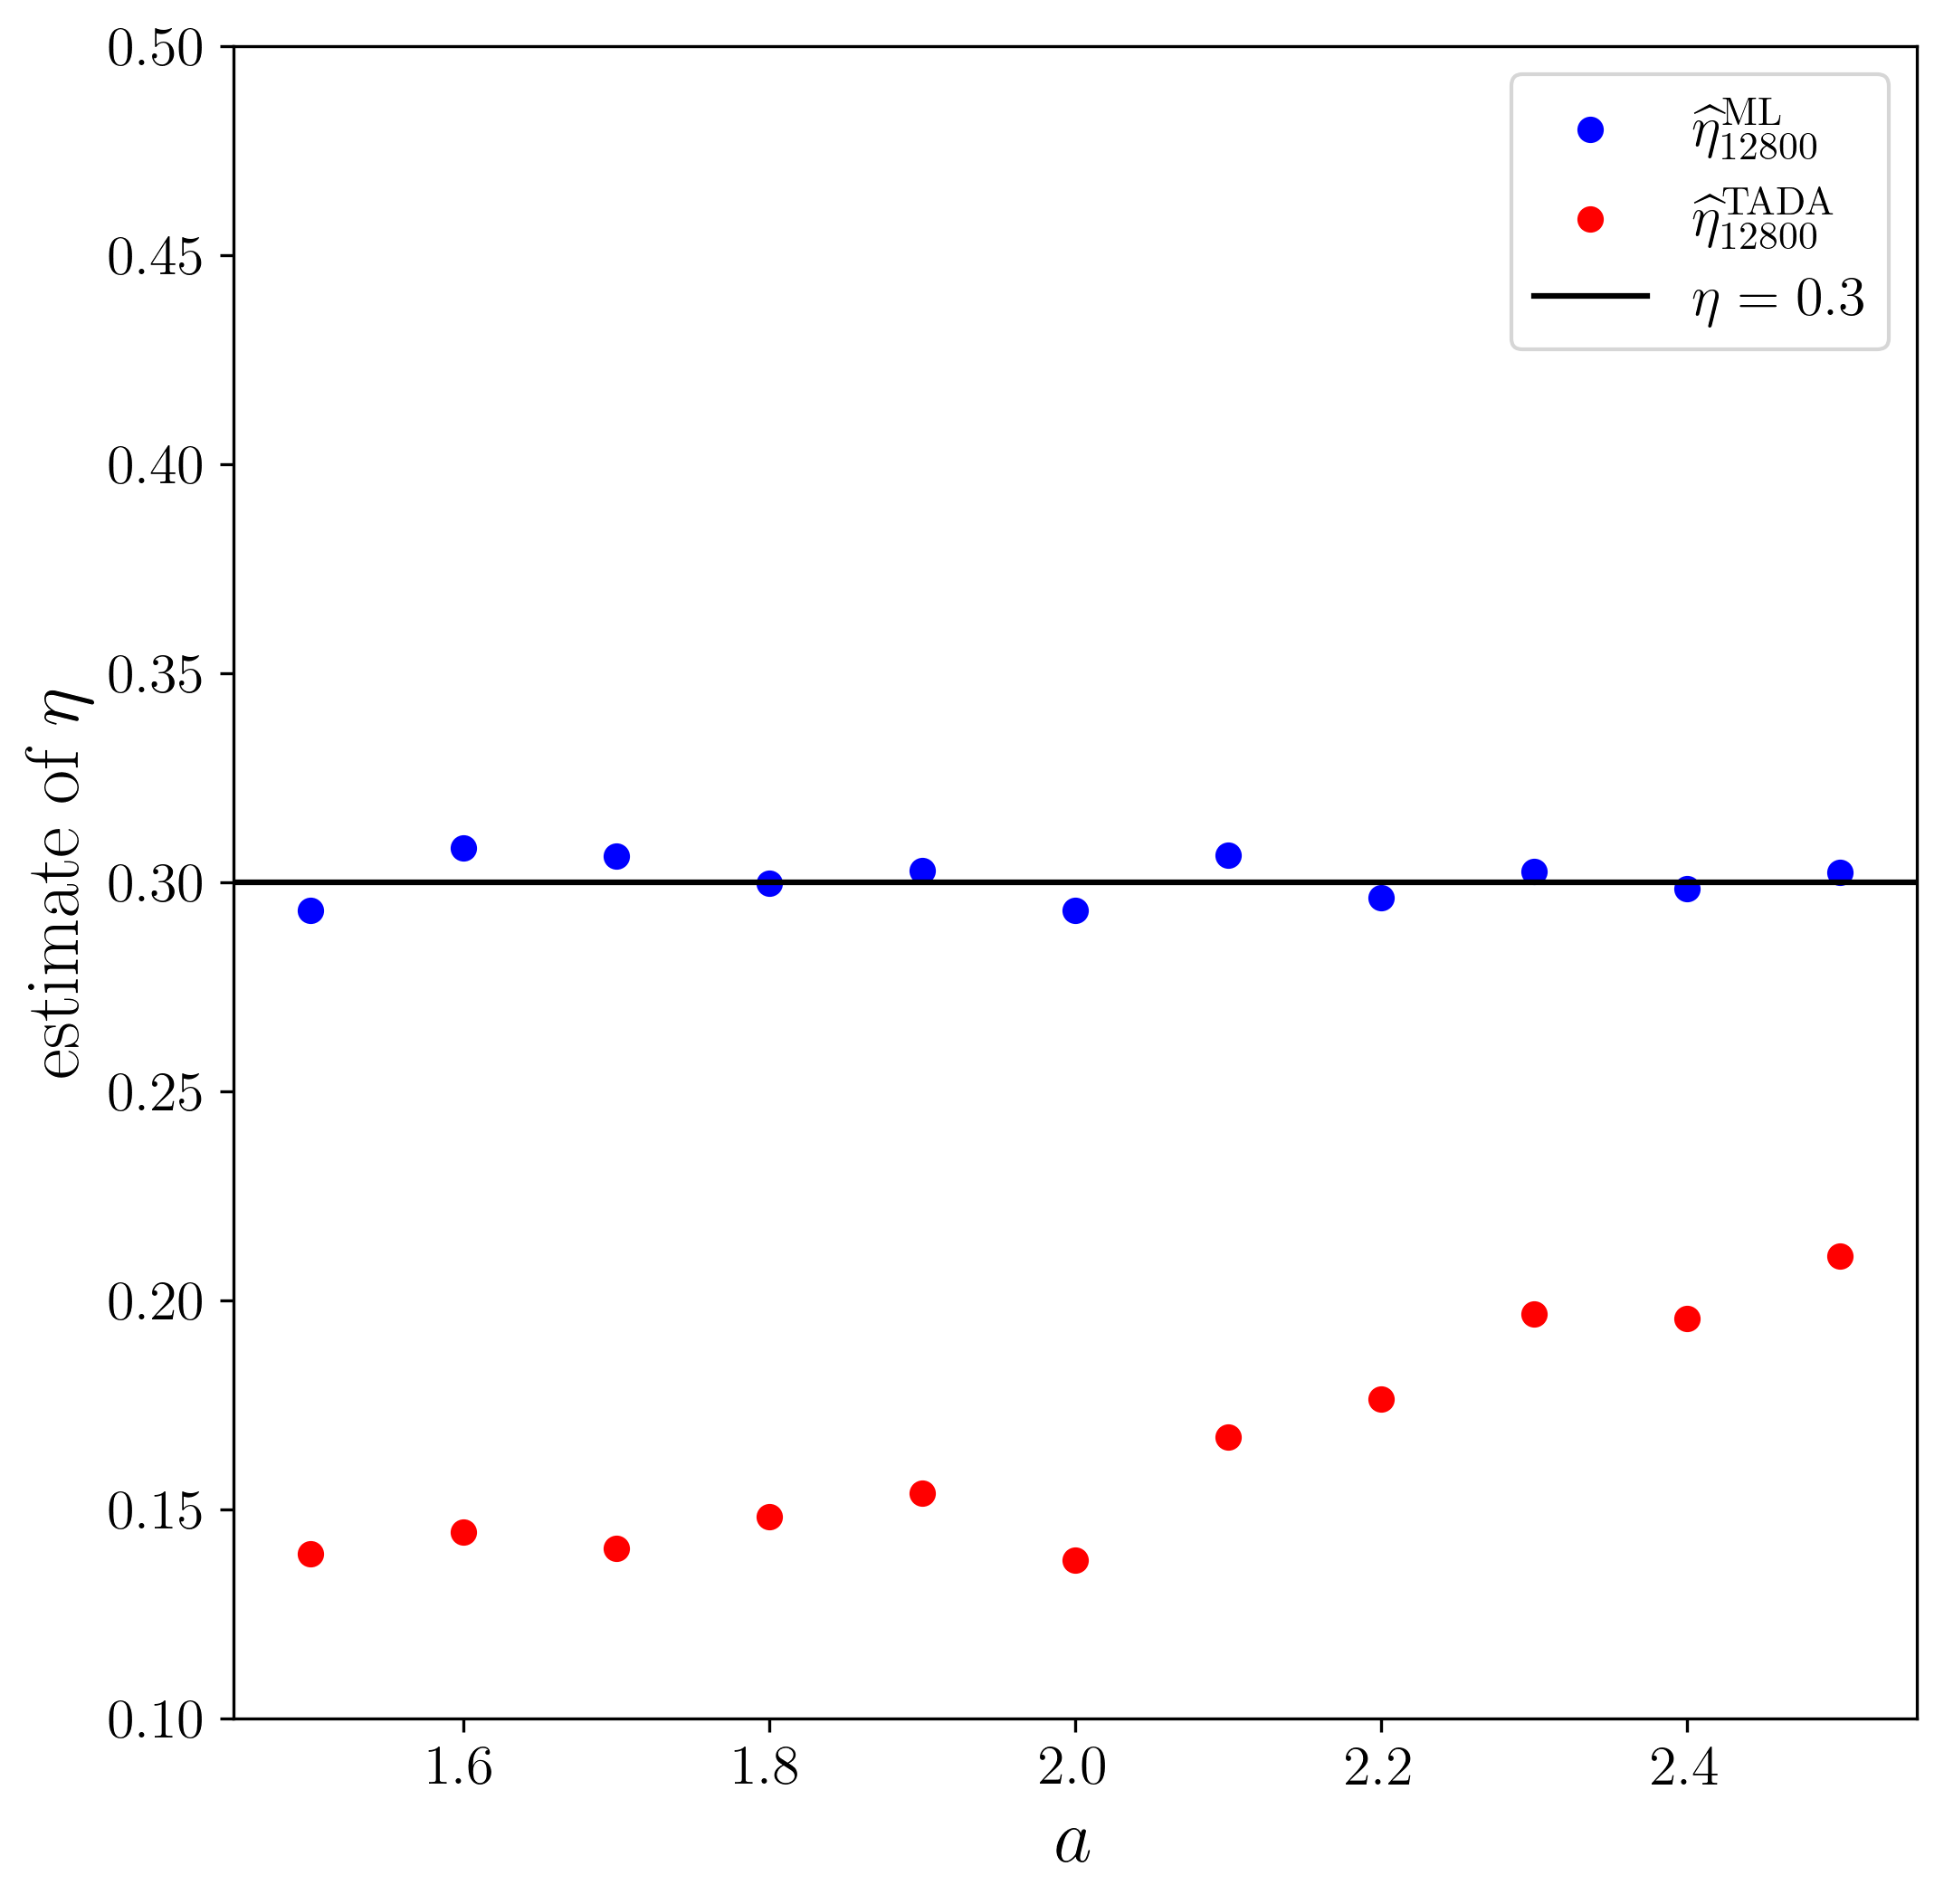

In [13]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 2],
    paras_mle_arr[num_data_idx, :, 0],
    label=rf"$\widehat{{\eta}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 2],
    paras_tada_arr[num_data_idx, :, 0],
    label=rf"$\widehat{{\eta}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 0], 0, 1, c="k", label=rf"$\eta={paras_true_arr[num_data_idx, 0, 0]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$a$", fontsize=20)
ax.set_ylabel(r"estimate of $\eta$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((1.45, 2.55))
ax.set_ylim((0.1, 0.5))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

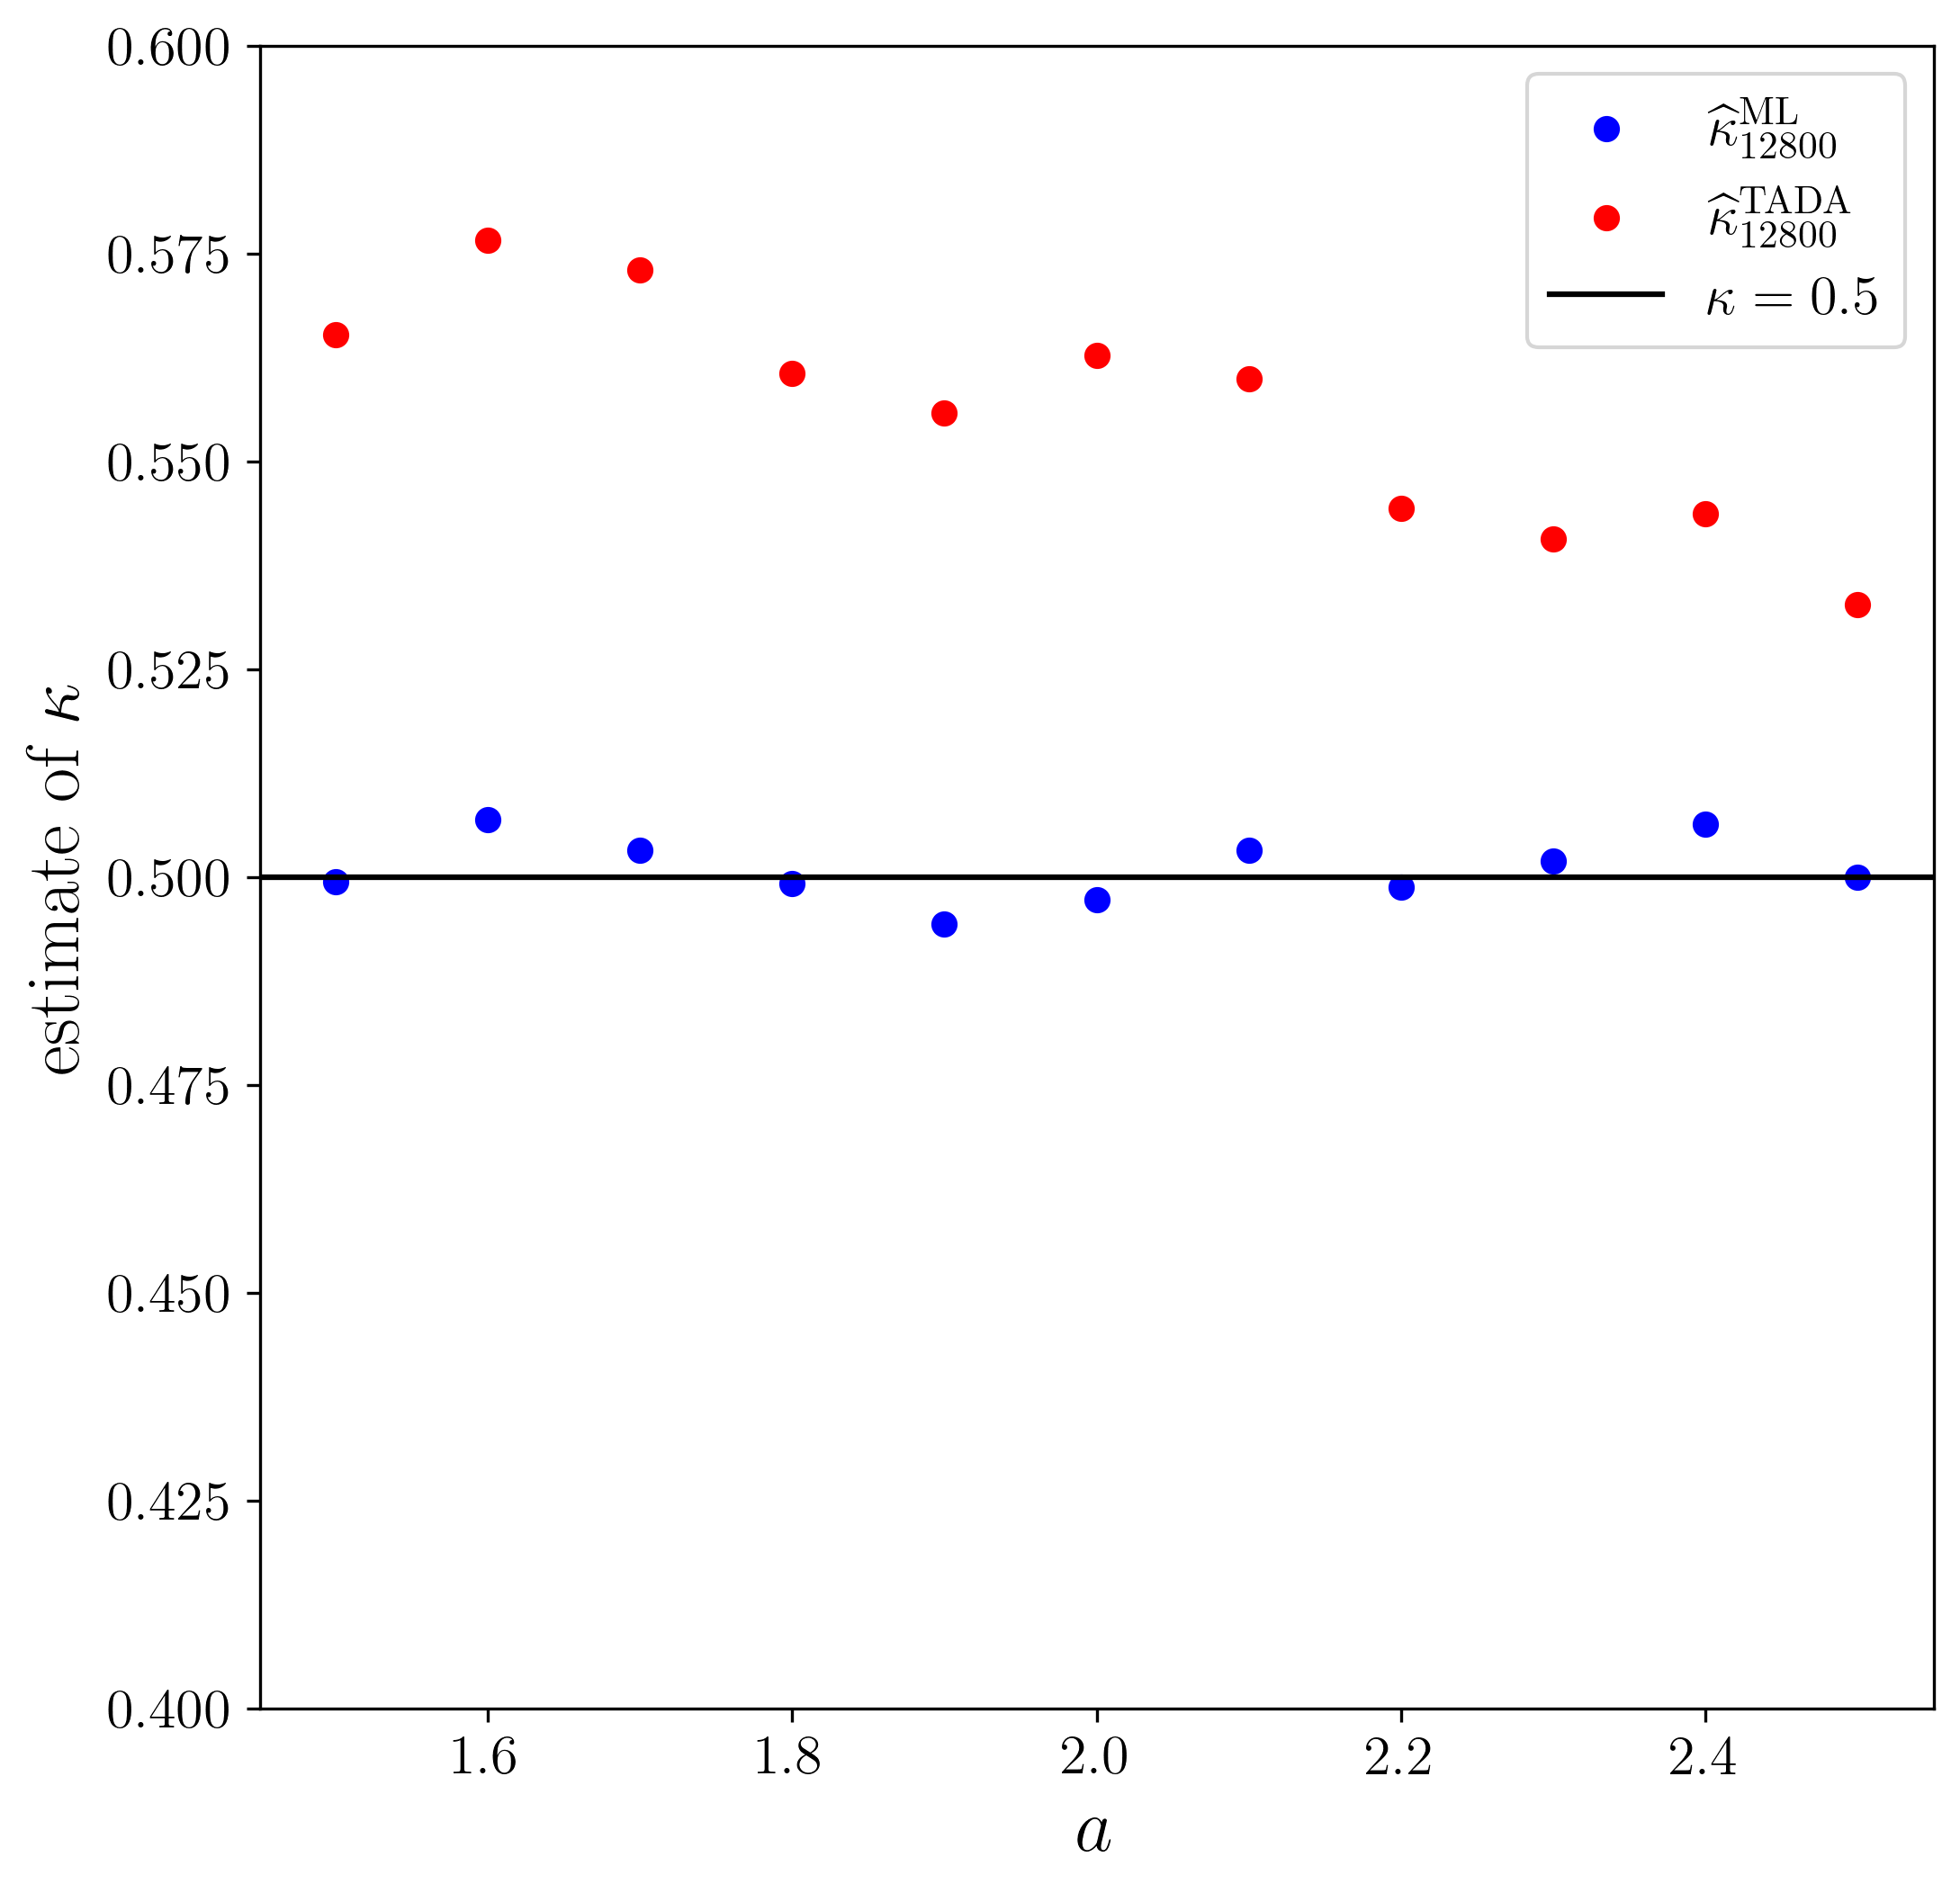

In [16]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 2],
    paras_mle_arr[num_data_idx, :, 1],
    label=rf"$\widehat{{\kappa}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 2],
    paras_tada_arr[num_data_idx, :, 1],
    label=rf"$\widehat{{\kappa}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 1], 0, 1, c="k", label=rf"$\kappa={paras_true_arr[num_data_idx, 0, 1]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$a$", fontsize=20)
ax.set_ylabel(r"estimate of $\kappa$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((1.45, 2.55))
ax.set_ylim((0.4, 0.6))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

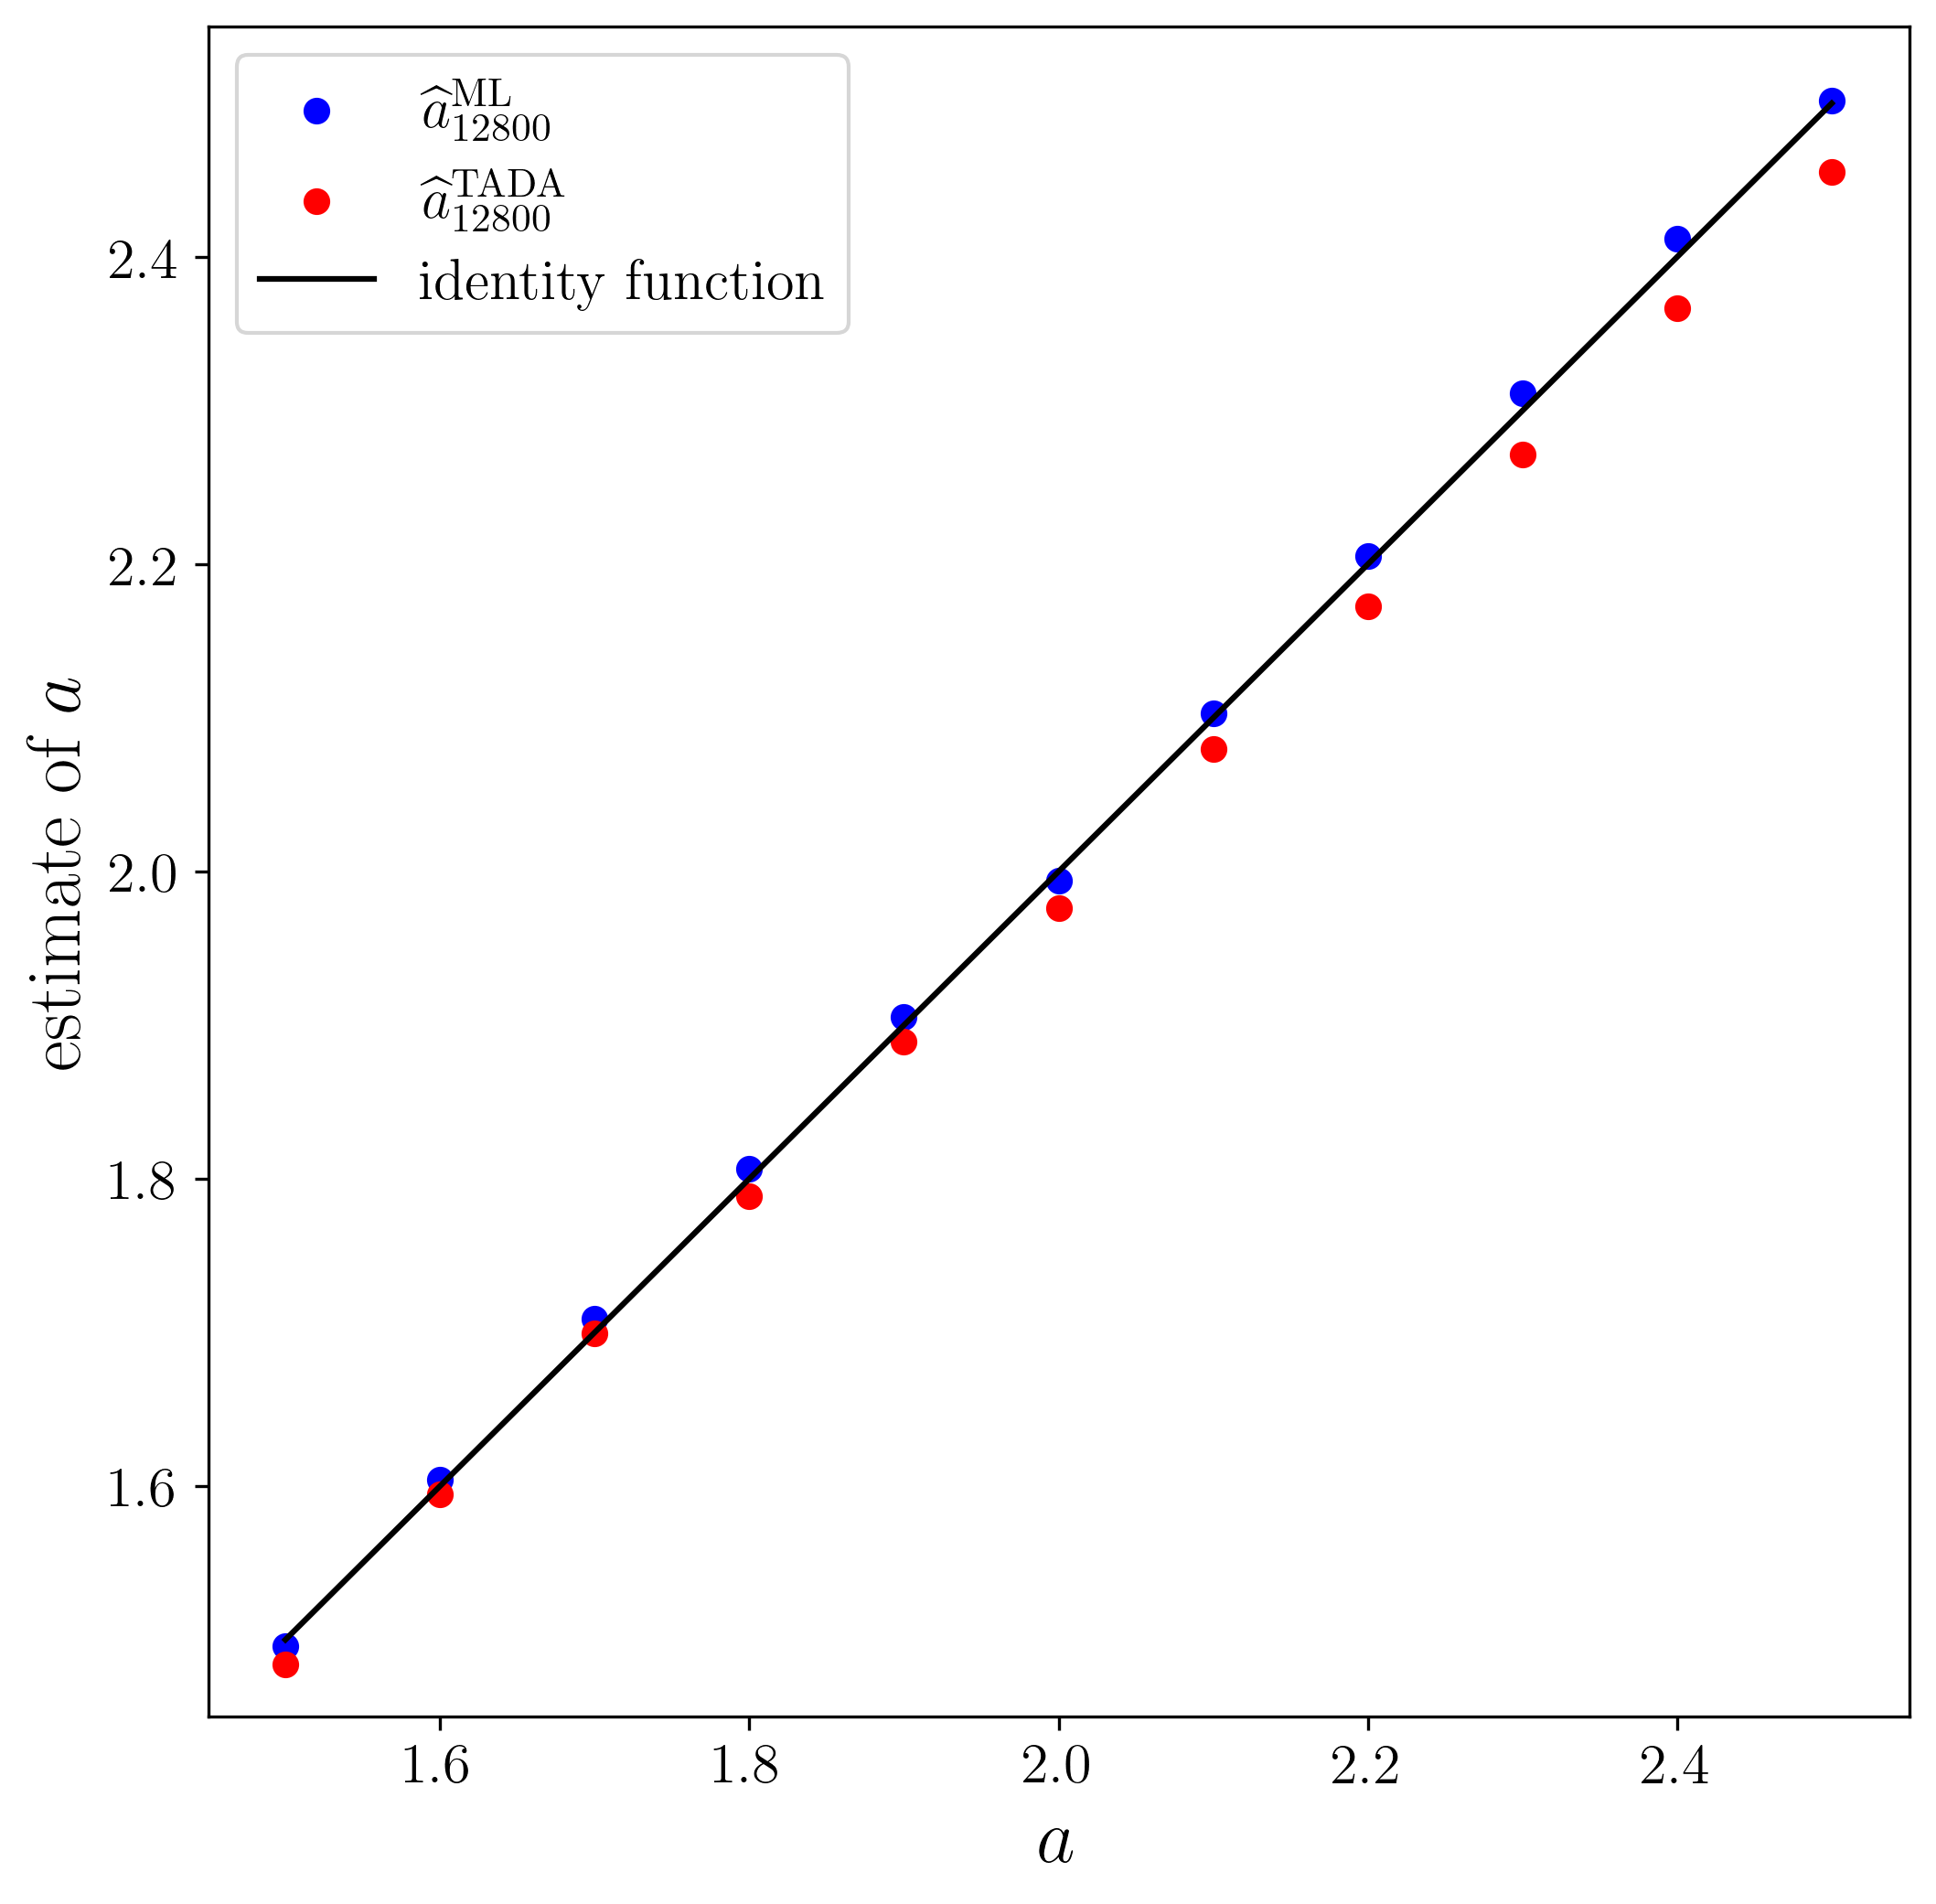

In [18]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 2],
    paras_mle_arr[num_data_idx, :, 2],
    label=rf"$\widehat{{a}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 2],
    paras_tada_arr[num_data_idx, :, 2],
    label=rf"$\widehat{{a}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.plot(
    np.linspace(1.5, 2.5, 100), np.linspace(1.5, 2.5, 100), c="k", label="identity function"
)
ax.legend(fontsize=15)
ax.set_xlabel(r"$a$", fontsize=20)
ax.set_ylabel(r"estimate of $a$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((1.45, 2.55))
ax.set_ylim((1.45, 2.55))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

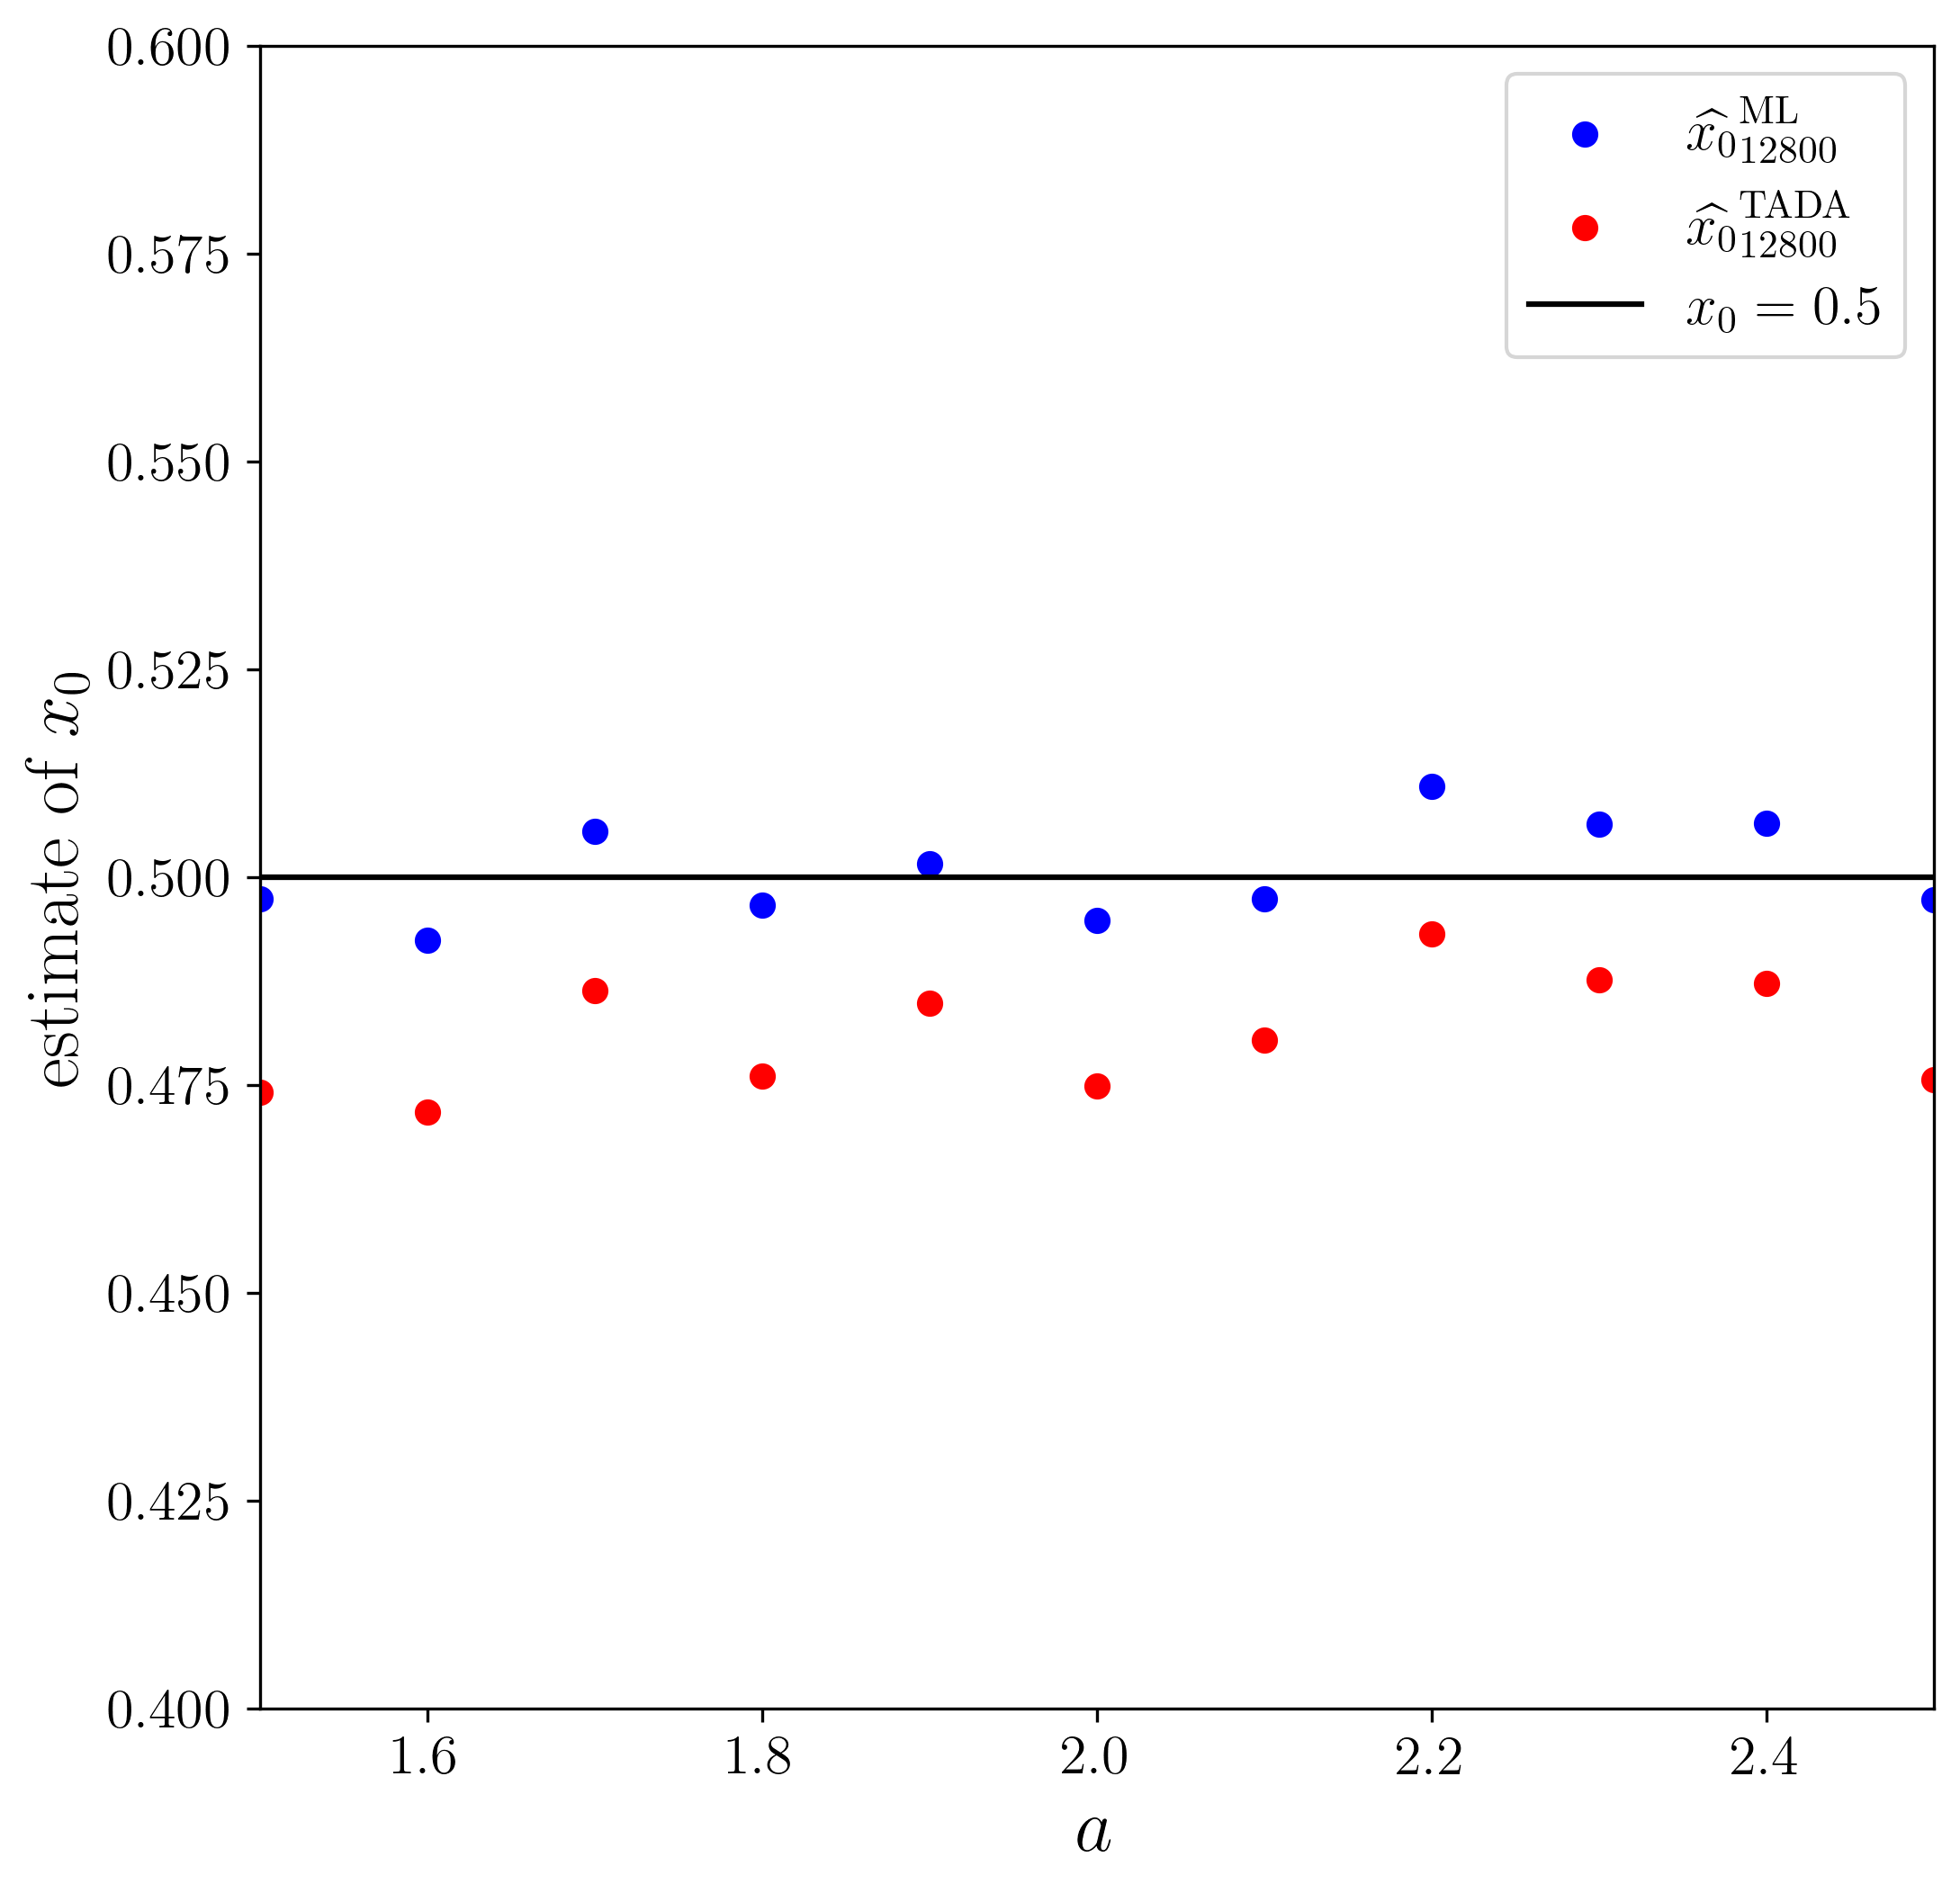

In [21]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 2],
    paras_mle_arr[num_data_idx, :, 3],
    label=rf"$\widehat{{x_0}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 2],
    paras_tada_arr[num_data_idx, :, 3],
    label=rf"$\widehat{{x_0}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 3], 0, 1, c="k", label=rf"$x_0={paras_true_arr[num_data_idx, 0, 3]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$a$", fontsize=20)
ax.set_ylabel(r"estimate of $x_0$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((1.5, 2.5))
ax.set_ylim((0.4, 0.6))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()